
<div style="background-color: #3498db; color: #ffffff; padding: 20px; text-align: center; font-family: 'Arial', sans-serif; font-size: 20px; border-radius: 10px; box-shadow: 3px 3px 5px 0px rgba(0,0,0,0.5);">
<h1> Smart Career Guidance System For Women</h1>
<h3>Machine Learning Based Career Recommendation System</h3>
</div>



##  Project Overview
This project uses Machine Learning to recommend suitable career paths based on:
- Education
- Skills
- Interests
- Age
- Recommendation Score

The goal is to empower women with data-driven career guidance.


<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Import Required Libraries</h3></div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Load Dataset</h3></div>

In [ ]:
df = pd.read_csv("career_dataset.csv")
df.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,1,John Doe,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,2,Jane Smith,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,3,Bob Johnson,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88
3,4,Emily Davis,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,AI Researcher,0.93
4,5,Michael Brown,30,Master's,Project Management;Communication;Agile,Business;Management,Project Manager,0.87


<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Basic Data Exploration</h3></div>

In [4]:
print("Shape:", df.shape)
df.info()
df.describe(include="all")

Shape: (200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CandidateID           200 non-null    int64  
 1   Name                  200 non-null    object 
 2   Age                   200 non-null    int64  
 3   Education             200 non-null    object 
 4   Skills                200 non-null    object 
 5   Interests             200 non-null    object 
 6   Recommended_Career    200 non-null    object 
 7   Recommendation_Score  200 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 12.6+ KB


,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
count,200.000000,200,200.000000,200,200,200,200,200.000000
unique,NaN,200,NaN,3,58,47,32,NaN
top,NaN,John Doe,NaN,Bachelor's,HTML;CSS;JavaScript,Finance;Analytics,Data Analyst,NaN
freq,NaN,1,NaN,92,9,15,21,NaN
mean,100.500000,NaN,30.125000,NaN,NaN,NaN,NaN,0.896450
std,57.879185,NaN,4.923472,NaN,NaN,NaN,NaN,0.028915
min,1.000000,NaN,22.000000,NaN,NaN,NaN,NaN,0.850000
25%,50.750000,NaN,26.750000,NaN,NaN,NaN,NaN,0.870000
50%,100.500000,NaN,29.000000,NaN,NaN,NaN,NaN,0.900000
75%,150.250000,NaN,33.000000,NaN,NaN,NaN,NaN,0.920000


<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Data Cleaning</h3></div>

In [5]:
df.drop_duplicates(inplace=True)
df.fillna("Unknown", inplace=True)
df.drop(["CandidateID","Name"], axis=1, errors="ignore", inplace=True)
df.head()

,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88
3,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,AI Researcher,0.93
4,30,Master's,Project Management;Communication;Agile,Business;Management,Project Manager,0.87


<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Encode Categorical Features</h3></div>

In [6]:
encoders = {}

for col in ["Education", "Skills", "Interests", "Recommended_Career"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,28,0,38,38,12,0.95
1,32,1,26,32,29,0.90
2,24,0,19,6,30,0.88
3,26,0,43,24,0,0.93
4,30,1,33,10,25,0.87


<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Feature Scaling</h3></div>

In [7]:
scaler = MinMaxScaler()
df[["Age","Recommendation_Score"]] = scaler.fit_transform(
    df[["Age","Recommendation_Score"]]
)

<div style="background-color: #3498db; color: #ffffff;padding:12px; border-radius:8px;"><h3> Data Visualization</h3></div>

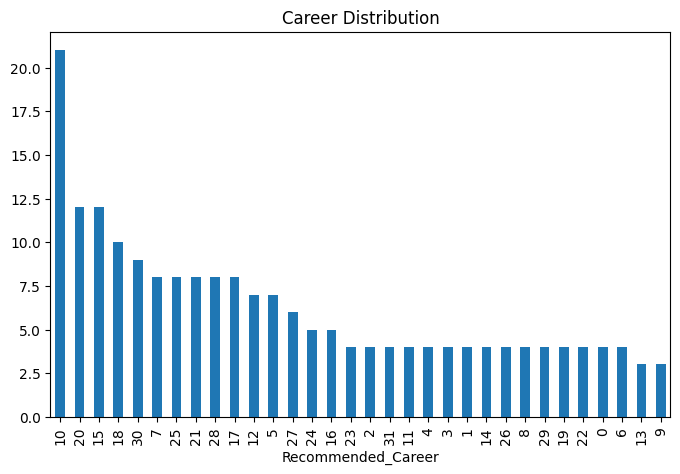

In [8]:
plt.figure(figsize=(8,5))
df["Recommended_Career"].value_counts().plot(kind="bar")
plt.title("Career Distribution")
plt.show()

<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Model Training</h3></div>

In [9]:
X = df.drop("Recommended_Career", axis=1)
y = df["Recommended_Career"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Model Evaluation</h3></div>

In [10]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           2       1.00      1.00      1.00         1
           3       0.50      1.00      0.67         1
           4       0.00      0.00      0.00         2
           5       1.00      0.50      0.67         2
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1
           8       1.00      0.33      0.50         3
          10       0.20      0.25      0.22         4
          11       0.00      0.00      0.00         0
          12       1.00      0.50      0.67         2
          13       0.00      0.00      0.00         1
          15       0.60      0.60      0.60         5
          16       0.50      1.00      0.67         1
          17       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         1
          19       1.00      1.00      1.00         1
          20 

C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\Lib\site-pa

<div style="background-color: #3498db; color: #ffffff; padding:12px; border-radius:8px;"><h3> Save Model</h3></div>

In [11]:
joblib.dump(model, "career_guidance_model.pkl")
print("Model saved successfully")

Model saved successfully
